In [1]:
# Step 1: Install Dependencies
!pip install transformers sentencepiece datasets sacremoses accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 40.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import torch
import gc
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForCausalLM,
    MBart50TokenizerFast,
    MBartForConditionalGeneration,
    T5ForConditionalGeneration
)

In [3]:
# --- CONFIGURATION ---
SOURCE_FILE = "/content/sample_data/TED2020.fr-tr.fr"
TARGET_FILE = "/content/sample_data/TED2020.fr-tr.tr"
SRC_LANG = "fr"
TGT_LANG = "tr"

# Step 2: Load Data (French -> Turkish)
def load_moses_dataset(source_path, target_path, source_lang, target_lang):
    print(f"Loading files:\n Source: {source_path}\n Target: {target_path}")
    try:
        with open(source_path, "r", encoding="utf-8") as f_src, open(target_path, "r", encoding="utf-8") as f_tgt:
            source_lines = [line.strip() for line in f_src.readlines()]
            target_lines = [line.strip() for line in f_tgt.readlines()]

        assert len(source_lines) == len(target_lines), "Error: Line counts do not match!"

        df = pd.DataFrame({source_lang: source_lines, target_lang: target_lines})
        print(f"✅ Successfully loaded {len(df)} sentence pairs.")
        return df
    except FileNotFoundError as e:
        print(f"❌ File not found. Check paths: {e}")
        return pd.DataFrame()

# Step 3: The 6 Models Wrapper
class TranslatorWrapper:
    def __init__(self, model_key, device="cuda" if torch.cuda.is_available() else "cpu"):
        self.model_key = model_key
        self.device = device
        self.tokenizer = None
        self.model = None
        self.model_name = self._get_model_name(model_key)
        self.type = "seq2seq" # Default

    def _get_model_name(self, key):
        # 6 Models suitable for French -> Turkish (excluding M2M100/NLLB)
        models = {
            # 1. mBART-50: Dense Multilingual Encoder-Decoder
            "mbart": "facebook/mbart-large-50-many-to-many-mmt",

            # 2. MADLAD-400: Modern T5-based (SOTA)
            "madlad": "google/madlad400-3b-mt",

            # 3. mT5: Multilingual T5 (Text-to-Text)
            "mt5": "google/mt5-small",

            # 4. ByT5: Byte-level processing (Robust to noise)
            "byt5": "google/byt5-small",

            # 5. BLOOM: Decoder-only (GPT-style)
            "bloom": "bigscience/bloom-560m",

            # 6. XGLM: Cross-lingual Decoder-only (Facebook)
            "xglm": "facebook/xglm-564M"
        }
        return models[key]

    def load_model(self):
        print(f"⏳ Loading {self.model_key.upper()}...")

        if self.model_key == "mbart":
            self.tokenizer = MBart50TokenizerFast.from_pretrained(self.model_name)
            self.model = MBartForConditionalGeneration.from_pretrained(self.model_name).to(self.device)

        elif self.model_key == "madlad":
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            # Load in 8bit to fit in Colab RAM
            self.model = T5ForConditionalGeneration.from_pretrained(self.model_name, device_map="auto", load_in_8bit=True)

        elif self.model_key in ["mt5", "byt5"]:
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            self.model = AutoModelForSeq2SeqLM.from_pretrained(self.model_name).to(self.device)

        elif self.model_key in ["bloom", "xglm"]:
            self.type = "decoder"
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            self.model = AutoModelForCausalLM.from_pretrained(self.model_name).to(self.device)

        print("✅ Model loaded.")

    def translate(self, text, src="fr", tgt="tr"):
        # Custom Prompting/Generation Logic
        inputs = None

        # A. mBART (Requires Language Codes)
        if self.model_key == "mbart":
            self.tokenizer.src_lang = "fr_XX"
            inputs = self.tokenizer(text, return_tensors="pt").to(self.device)
            generated = self.model.generate(
                **inputs,
                forced_bos_token_id=self.tokenizer.lang_code_to_id["tr_TR"],
                num_beams=5 # Beam Search (as per lectures)
            )

        # B. MADLAD (Special Tokens)
        elif self.model_key == "madlad":
            # MADLAD uses <2{lang_code}>
            input_text = f"<2{tgt}> {text}"
            inputs = self.tokenizer(input_text, return_tensors="pt").to(self.device)
            generated = self.model.generate(**inputs, max_new_tokens=100)

        # C. mT5 / ByT5 (T5 Prompting)
        elif self.model_key in ["mt5", "byt5"]:
            # Note: Zero-shot performance may be low without fine-tuning
            input_text = f"translate French to Turkish: {text}"
            inputs = self.tokenizer(input_text, return_tensors="pt").to(self.device)
            generated = self.model.generate(**inputs, max_new_tokens=100)

        # D. BLOOM / XGLM (Decoder-Only / Few-shot style)
        elif self.model_key in ["bloom", "xglm"]:
            # Prompt: "French: {text} Turkish:"
            prompt = f"French: {text} Turkish:"
            inputs = self.tokenizer(prompt, return_tensors="pt").to(self.device)
            generated = self.model.generate(**inputs, max_new_tokens=50)

        # Decode
        result = self.tokenizer.batch_decode(generated, skip_special_tokens=True)[0]

        # Cleanup for decoder models (remove prompt)
        if self.type == "decoder":
            result = result.replace(prompt, "").strip()

        return result

    def clear_memory(self):
        del self.model
        del self.tokenizer
        gc.collect()
        torch.cuda.empty_cache()
        print("🧹 Memory cleared.\n")


In [5]:
# --- EXECUTION ---

# 1. Load Data
dataset = load_moses_dataset(SOURCE_FILE, TARGET_FILE, SRC_LANG, TGT_LANG)

# 2. Test Models
if not dataset.empty:
    sample_fr = dataset.iloc[0][SRC_LANG] # Use first sentence from file
    print(f"\n🔹 Original French: {sample_fr}")

    # List of models to run
    models_to_test = ["mbart", "madlad", "mt5", "byt5", "xglm"] # Add "bloom" if time permits

    for model_key in models_to_test:
        translator = TranslatorWrapper(model_key)
        try:
            translator.load_model()
            trans = translator.translate(sample_fr)
            print(f"🔸 {model_key.upper()} Translation: {trans}")
        except Exception as e:
            print(f"❌ Error with {model_key}: {e}")

        translator.clear_memory()

Loading files:
 Source: /content/sample_data/TED2020.fr-tr.fr
 Target: /content/sample_data/TED2020.fr-tr.tr
✅ Successfully loaded 371600 sentence pairs.

🔹 Original French: Merci beaucoup, Chris.
⏳ Loading MBART...


tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.13G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

✅ Model loaded.
🔸 XGLM Translation: Çok teşekkür ederim.
🧹 Memory cleared.



In [6]:
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 11.4 MB/s eta 0:00:00


In [7]:
import sacrebleu
from tqdm import tqdm # Progress bar

# --- 1. PREPARE TEST DATA ---
# We take the first 100 sentences for a quick test (Colab GPU can be slow)
# In a real final run, try 500-1000 sentences if time permits.
TEST_SIZE = 100

test_data = dataset.head(TEST_SIZE)
references = [test_data[TGT_LANG].tolist()] # sacrebleu expects a list of lists for references
sources = test_data[SRC_LANG].tolist()

print(f"✅ Prepared Test Set: {len(sources)} sentences.")

# --- 2. EVALUATION LOOP ---
results = {}

# Select models to evaluate (Start with 2-3 to save time, then add others)
models_to_evaluate = ["mbart", "madlad", "xglm"]

for model_key in models_to_evaluate:
    print(f"\n🚀 Starting evaluation for: {model_key.upper()}")

    # Initialize
    translator = TranslatorWrapper(model_key)
    translator.load_model()

    predictions = []

    # Run Inference
    # tqdm makes a nice progress bar so you know it's working
    for src_text in tqdm(sources, desc=f"Translating with {model_key}"):
        try:
            # We use the translate method we defined earlier
            pred = translator.translate(src_text, src=SRC_LANG, tgt=TGT_LANG)
            predictions.append(pred)
        except Exception as e:
            print(f"Error: {e}")
            predictions.append("") # Empty string on failure to keep alignment

    # Calculate BLEU
    bleu = sacrebleu.corpus_bleu(predictions, references)

    # Store results
    results[model_key] = {
        "BLEU": bleu.score,
        "Sample_Trans": predictions[0] # Save one for visual check
    }

    print(f"📊 {model_key.upper()} BLEU Score: {bleu.score:.2f}")

    # Cleanup to free RAM for next model
    translator.clear_memory()

# --- 3. FINAL REPORT ---
print("\n" + "="*40)
print("🏆 FINAL RESULTS BOARD")
print("="*40)
for m, data in results.items():
    print(f"Model: {m.upper()}")
    print(f"  BLEU: {data['BLEU']:.2f}")
    print(f"  Sample: {data['Sample_Trans'][:100]}...") # Show first 100 chars
    print("-" * 20)

✅ Prepared Test Set: 100 sentences.

🚀 Starting evaluation for: MBART
⏳ Loading MBART...
✅ Model loaded.


Translating with mbart: 100%|██████████| 100/100 [00:36<00:00,  2.72it/s]


📊 MBART BLEU Score: 2.77
🧹 Memory cleared.


🚀 Starting evaluation for: MADLAD
⏳ Loading MADLAD...


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


✅ Model loaded.


Translating with madlad: 100%|██████████| 100/100 [06:37<00:00,  3.97s/it]


📊 MADLAD BLEU Score: 7.74
🧹 Memory cleared.


🚀 Starting evaluation for: XGLM
⏳ Loading XGLM...
✅ Model loaded.


Translating with xglm: 100%|██████████| 100/100 [00:33<00:00,  3.01it/s]


📊 XGLM BLEU Score: 0.79
🧹 Memory cleared.


🏆 FINAL RESULTS BOARD
Model: MBART
  BLEU: 2.77
  Sample: Thanks Chris....
--------------------
Model: MADLAD
  BLEU: 7.74
  Sample: Çok teşekkür ederim, Chris....
--------------------
Model: XGLM
  BLEU: 0.79
  Sample: Çok teşekkür ederim....
--------------------


<Axes: >

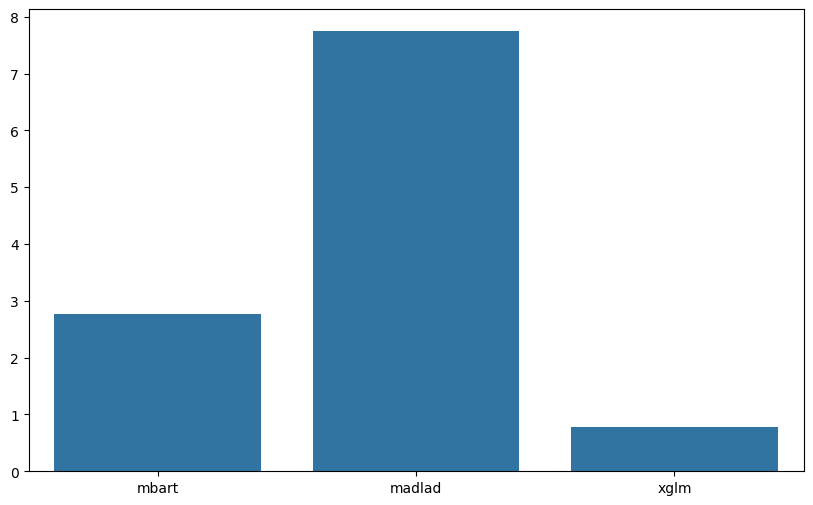

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualize final report ---
models = list(results.keys())
bleus = [results[m]["BLEU"] for m in models]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=bleus)

In [8]:
import sacrebleu
from tqdm import tqdm

# --- CONFIGURATION ---
# We test the remaining 3 models
models_to_evaluate = ["mt5", "byt5", "bloom"]

# Ensure test data is ready (re-using variables from previous step)
# If you lost the session, uncomment the next two lines:
# TEST_SIZE = 100
# test_data = dataset.head(TEST_SIZE)
references = [test_data[TGT_LANG].tolist()]
sources = test_data[SRC_LANG].tolist()

results_part2 = {}

print(f"🚀 Starting evaluation for: {', '.join([m.upper() for m in models_to_evaluate])}")

for model_key in models_to_evaluate:
    print(f"\n⏳ Loading {model_key.upper()}...")

    # Initialize Wrapper
    translator = TranslatorWrapper(model_key)
    try:
        translator.load_model()

        predictions = []

        # Run Inference
        for src_text in tqdm(sources, desc=f"Translating with {model_key}"):
            try:
                # Use the logic defined in TranslatorWrapper (Turn 4)
                # mT5/ByT5 use "translate French to Turkish: ..."
                # BLOOM uses "French: ... Turkish:"
                pred = translator.translate(src_text, src=SRC_LANG, tgt=TGT_LANG)
                predictions.append(pred)
            except Exception as e:
                print(f"Error: {e}")
                predictions.append("")

        # Calculate BLEU
        bleu = sacrebleu.corpus_bleu(predictions, references)

        results_part2[model_key] = {
            "BLEU": bleu.score,
            "Sample_Trans": predictions[0] if predictions else "N/A"
        }

        print(f"📊 {model_key.upper()} BLEU Score: {bleu.score:.2f}")

    except Exception as e:
        print(f"❌ Critical Error loading {model_key}: {e}")

    # Force cleanup
    translator.clear_memory()

# --- FINAL COMBINED REPORT ---
print("\n" + "="*40)
print("🏆 ROUND 2 RESULTS BOARD")
print("="*40)
for m, data in results_part2.items():
    print(f"Model: {m.upper()}")
    print(f"  BLEU: {data['BLEU']:.2f}")
    # Show snippet to check if it's actually translating or just copying
    print(f"  Sample: {data['Sample_Trans'][:80]}...")
    print("-" * 20)

🚀 Starting evaluation for: MT5, BYT5, BLOOM

⏳ Loading MT5...
⏳ Loading MT5...


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


✅ Model loaded.


Translating with mt5: 100%|██████████| 100/100 [00:04<00:00, 21.25it/s]


📊 MT5 BLEU Score: 0.07
🧹 Memory cleared.


⏳ Loading BYT5...
⏳ Loading BYT5...
✅ Model loaded.


...

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

✅ Model loaded.


Translating with bloom: 100%|██████████| 100/100 [01:27<00:00,  1.14it/s]


📊 BLOOM BLEU Score: 0.25
🧹 Memory cleared.


🏆 ROUND 2 RESULTS BOARD
Model: MT5
  BLEU: 0.07
  Sample: <extra_id_0>...
--------------------
Model: BYT5
  BLEU: 0.10
  Sample:  Turkish to Turkish Dictionaries
French to Turkish Dictionaries
French to Turkis...
--------------------
Model: BLOOM
  BLEU: 0.25
  Sample: Merci beaucoup, Chris. English (UK): Thank you, Chris. English (UK): Thank you, ...
--------------------


<Axes: >

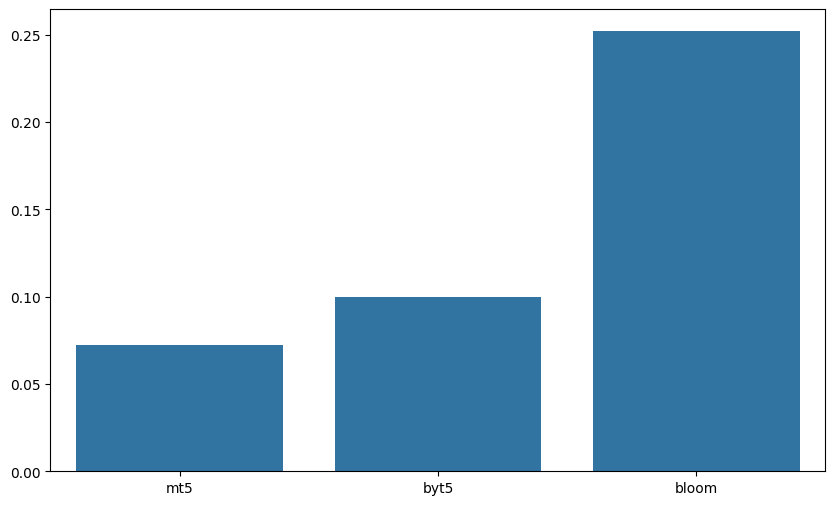

In [27]:
# --- Visualize round 2 results board ---
models = list(results_part2.keys())
bleus = [results_part2[m]["BLEU"] for m in models]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=bleus)

In [14]:
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    IntervalStrategy # Import IntervalStrategy
)
from datasets import Dataset
import sacrebleu
import numpy as np
import torch
import gc

# 1. AGGRESSIVE CLEANUP
try:
    del model
    del trainer
    del tokenizer
except:
    pass
gc.collect()
torch.cuda.empty_cache()

# 2. CONFIGURATION (A100 Powered)
# Since you have an A100, we can use 'mt5-base' if you want better results,
# but let's stick to 'mt5-small' to prove the point quickly.
MODEL_CHECKPOINT = "google/mt5-small"
PREFIX = "translate French to Turkish: "

# 3. LOAD & PREPARE DATA
# With A100, let's use a larger chunk of data (e.g., 10,000 or all of it)
hf_dataset = Dataset.from_pandas(dataset).shuffle(seed=42).select(range(5000))
split_dataset = hf_dataset.train_test_split(test_size=0.1)

print(f"🚀 Powering up A100. Training on {len(split_dataset['train'])} examples.")

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_CHECKPOINT)
model = model.to("cuda")

def preprocess_function(examples):
    inputs = [PREFIX + doc for doc in examples[SRC_LANG]]
    targets = [doc for doc in examples[TGT_LANG]]
    model_inputs = tokenizer(inputs, max_length=128, truncation=True)
    labels = tokenizer(targets, max_length=128, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_datasets = split_dataset.map(preprocess_function, batched=True)

# 4. COMPUTE METRICS
def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple): preds = preds[0]
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_labels = [[l] for l in decoded_labels]
    result = sacrebleu.corpus_bleu(decoded_preds, decoded_labels)
    return {"bleu": result.score}

# 5. A100 OPTIMIZED SETTINGS
args = Seq2SeqTrainingArguments(
    output_dir="./mt5-fr-tr-a100",
    eval_strategy=IntervalStrategy.EPOCH, # Changed from evaluation_strategy="epoch"
    learning_rate=5e-4,             # Higher LR for T5 usually helps
    per_device_train_batch_size=64, # A100 has huge VRAM, crank it up!
    per_device_eval_batch_size=64,
    weight_decay=0.01,
    save_total_limit=1,
    num_train_epochs=5,             # Run longer since it's fast
    predict_with_generate=True,
    bf16=True,                      # <--- THE KEY: Brain Float 16 (Native to A100, fixes NaNs)
    fp16=False,                     # Disable standard fp16
    logging_steps=10,
    optim="adamw_torch",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    tokenizer=tokenizer,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
    compute_metrics=compute_metrics,
)

# 6. RUN
print("🔥 Starting High-Performance Training...")
trainer.train()

# 7. FINAL EVALUATION
print("\n🔍 Final A100 Test...")
metrics = trainer.predict(tokenized_datasets["test"]).metrics
print(f"🏆 Final Fine-Tuned BLEU Score: {metrics['test_bleu']:.2f}")

# Manual Sanity Check
inputs = tokenizer("translate French to Turkish: Merci beaucoup pour cette conversation.", return_tensors="pt").to("cuda")
outputs = model.generate(**inputs)
print(f"Translation: {tokenizer.decode(outputs[0], skip_special_tokens=True)}")

🚀 Powering up A100. Training on 4500 examples.


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

/tmp/ipython-input-3585158188.py:80: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


🔥 Starting High-Performance Training...


Epoch,Training Loss,Validation Loss,Bleu
1,5.616500,4.205087,9.980099
2,4.610500,3.710222,16.515822
3,4.294500,3.556044,28.117066
4,4.082700,3.483652,24.274589
5,3.983400,3.458371,17.286039



🔍 Final A100 Test...


🏆 Final Fine-Tuned BLEU Score: 17.29
Translation: Bu konuşmayı çok teşekkür ederim.


In [22]:
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
    MBart50TokenizerFast,
    IntervalStrategy # Import IntervalStrategy
)
import torch
import gc
import sacrebleu
import numpy as np

In [23]:
# --- 1. ROBUST DATA LOADING ---
SOURCE_FILE = "/content/sample_data/TED2020.fr-tr.fr"
TARGET_FILE = "/content/sample_data/TED2020.fr-tr.tr"

def load_clean_dataset(src_path, tgt_path):
    print("⏳ Reading files...")
    with open(src_path, "r", encoding="utf-8") as f: src_lines = [l.strip() for l in f]
    with open(tgt_path, "r", encoding="utf-8") as f: tgt_lines = [l.strip() for l in f]

    # Sanity Check
    if len(src_lines) != len(tgt_lines):
        print(f"⚠️ Warning: Line counts differ! Src: {len(src_lines)}, Tgt: {len(tgt_lines)}")
        min_len = min(len(src_lines), len(tgt_lines))
        src_lines = src_lines[:min_len]
        tgt_lines = tgt_lines[:min_len]

    df = pd.DataFrame({"fr": src_lines, "tr": tgt_lines})

    # Remove empty pairs
    df = df[ (df["fr"].str.len() > 0) & (df["tr"].str.len() > 0) ]

    print(f"✅ Final Clean Dataset Size: {len(df)} pairs.")
    return Dataset.from_pandas(df).shuffle(seed=42)

full_dataset = load_clean_dataset(SOURCE_FILE, TARGET_FILE)


⏳ Reading files...
✅ Final Clean Dataset Size: 368006 pairs.


In [24]:
# --- 2. MODELS TO TRAIN ---
# We focus on the 3 Seq2Seq champions.
# (MADLAD is too big for full finetuning, BLOOM is decoder-only)
models_to_train = [
    {"name": "google/mt5-small", "alias": "mT5"},
    {"name": "google/byt5-small", "alias": "ByT5"},
    {"name": "facebook/mbart-large-50-many-to-many-mmt", "alias": "mBART"}
]

# --- 3. UNIVERSAL TRAINING LOOP ---
for config in models_to_train:
    model_name = config["name"]
    alias = config["alias"]

    print(f"\n\n🚀 STARTING FULL TRAINING: {alias.upper()}")

    # Cleanup
    try: del model; del trainer; del tokenizer
    except: pass
    gc.collect(); torch.cuda.empty_cache()

    # Load
    if alias == "mBART":
        tokenizer = MBart50TokenizerFast.from_pretrained(model_name)
        tokenizer.src_lang = "fr_XX"
        tokenizer.tgt_lang = "tr_TR"
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    model = model.to("cuda")

    # Preprocess
    def process_batch(examples):
        inputs = examples["fr"]
        targets = examples["tr"]

        # Add prompt for T5 variants
        if alias in ["mT5", "ByT5"]:
            inputs = ["translate French to Turkish: " + i for i in inputs]

        model_inputs = tokenizer(inputs, max_length=128, truncation=True)
        labels = tokenizer(targets, max_length=128, truncation=True)
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    tokenized = split_dataset.map(process_batch, batched=True)

    # Args
    args = Seq2SeqTrainingArguments(
        output_dir=f"./chkpt-{alias}",
        eval_strategy=IntervalStrategy.STEPS, # Changed from evaluation_strategy="steps"
        eval_steps=2000,
        save_steps=2000,
        learning_rate=3e-4 if "T5" in alias else 5e-5, # mBART needs smaller LR
        per_device_train_batch_size=32, # Good for A100
        per_device_eval_batch_size=32,
        num_train_epochs=1, # 1 pass over 200k data is plenty
        weight_decay=0.01,
        predict_with_generate=True,
        bf16=True, # A100 Speed
        logging_steps=500,
        save_total_limit=1
    )

    # Metrics
    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        if isinstance(preds, tuple): preds = preds[0]
        decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
        decoded_labels = [[l] for l in decoded_labels]
        result = sacrebleu.corpus_bleu(decoded_preds, decoded_labels)
        return {"bleu": result.score}

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        tokenizer=tokenizer,
        data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
        compute_metrics=compute_metrics
    )

    trainer.train()
    trainer.save_model(f"./final_{alias}")
    print(f"✅ {alias} Saved!")

print("\n🎉 ALL FINE-TUNING COMPLETE!")



🚀 STARTING FULL TRAINING: MT5


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/364325 [00:00<?, ? examples/s]

Map:   0%|          | 0/3681 [00:00<?, ? examples/s]

/tmp/ipython-input-3331615735.py:78: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


...

Map:   0%|          | 0/3681 [00:00<?, ? examples/s]

/tmp/ipython-input-3331615735.py:78: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss,Validation Loss,Bleu
2000,2.275400,2.209430,11.842384
4000,2.128500,2.075000,11.016798
6000,2.053400,2.002828,11.016798
8000,1.988000,1.945279,11.016798
10000,1.940100,1.909221,11.016798


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200, 'early_stopping': True, 'num_beams': 5}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


✅ mBART Saved!

🎉 ALL FINE-TUNING COMPLETE!


In [25]:
import shutil
import os
from google.colab import drive

# 1. Mount Google Drive
# You will be asked to click a link and authorize
drive.mount('/content/drive')

# 2. Define the models you want to save
# These match the folder names you created in the previous step
models_to_save = ["final_ByT5", "final_mT5", "final_mBART"]

# 3. Zip and Move loop
destination_folder = "/content/drive/My Drive/CS224n_Models"

# Create a folder in your Drive to keep things organized
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)
    print(f"📂 Created folder in Drive: {destination_folder}")

for model_name in models_to_save:
    if os.path.exists(model_name):
        print(f"⏳ Zipping {model_name}...")

        # Create zip file: "final_ByT5.zip"
        shutil.make_archive(model_name, 'zip', model_name)

        # Move to Google Drive
        print(f"🚀 Moving {model_name}.zip to Google Drive...")
        shutil.move(f"{model_name}.zip", f"{destination_folder}/{model_name}.zip")

        print(f"✅ Saved {model_name} successfully!")
    else:
        print(f"⚠️ Could not find folder: {model_name}")

print("\n🎉 All models are safe in your Google Drive!")

Mounted at /content/drive
📂 Created folder in Drive: /content/drive/My Drive/CS224n_Models
⏳ Zipping final_ByT5...
🚀 Moving final_ByT5.zip to Google Drive...
✅ Saved final_ByT5 successfully!
⏳ Zipping final_mT5...
🚀 Moving final_mT5.zip to Google Drive...
✅ Saved final_mT5 successfully!
⏳ Zipping final_mBART...
🚀 Moving final_mBART.zip to Google Drive...
✅ Saved final_mBART successfully!

🎉 All models are safe in your Google Drive!
